Showcase the categorization of customer feedback using fine-tuned GPT-2.

We have a dataset of customer feedback that we want to categorize into different categories. We will use the fine-tuned GPT-2 model to classify the feedback into different categories.

Main idea: Since GPT2 is a decoder transformer, the last token of the input sequence is used to make predictions about the next token that should follow the input. This means that the last token of the input sequence contains all the information needed in the prediction.

Imports

Import all needed libraries for this notebook.

Declare parameters used for this notebook:

set_seed(123) - Always good to set a fixed seed for reproducibility. epochs - Number of training epochs (authors recommend between 2 and 4). batch_size - Number of batches - depending on the max sequence length and GPU memory. For 512 sequence length a batch of 10 USUALY works without cuda memory issues. For small sequence length can try batch of 32 or higher. max_length - Pad or truncate text sequences to a specific length. I will set it to 60 to speed up training.



In [12]:
# Ensure this cell is run before any other code that initializes the model
import os
import torch

os.environ["CUDA_VISIBLE_DEVICES"] = "0"  # Use Nvidia GPU


#  Check if CUDA is available
if torch.cuda.is_available():
    print(f"CUDA is available. Using GPU: {torch.cuda.get_device_name(0)}")
else:
    print("CUDA is not available. Using CPU.")

CUDA is available. Using GPU: NVIDIA GeForce RTX 3070 Laptop GPU


In [13]:
from transformers import set_seed

# Set seed for reproducibility
set_seed(123)

# Number of training epochs (authors recommend between 2 and 4 for fine-tuning Bert)
epochs = 1000


# Number of batches - depending on the max length of the text
# For 512 sequence length batch of 10 works without cuda memory issues.
# For small sequence length can try batch of 32 or higher.
# Function to dynamically determine batch size based on available GPU memory
def get_dynamic_batch_size(base_batch_size=64, memory_threshold=0.8):
    if torch.cuda.is_available():
        total_memory = torch.cuda.get_device_properties(0).total_memory
        reserved_memory = torch.cuda.memory_reserved(0)
        available_memory = total_memory - reserved_memory
        dynamic_batch_size = int(base_batch_size * (available_memory / total_memory) * memory_threshold)
        return max(1, dynamic_batch_size)  # Ensure at least a batch size of 1
    else:
        return base_batch_size


# Dynamically determine batch size
batch_size = get_dynamic_batch_size()

print(f"Using batch size of {batch_size}")

# Look for gpu to use. Will use `cpu` by default if no gpu found.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Name of the GPT2 model to use
model_name = "gpt2"

# Dictionary of labels and their id
labels_ids = {"Low": 0, "Medium": 1, "High": 2}

# Dictionary of id and corresponding labels
ids_labels = {v: k for k, v in labels_ids.items()}
num_labels = len(labels_ids)

# Learning rate for the optimizer
optimizer_learning_rate = 2e-5

# Epsilon parameter for the optimizer. It is a very small number to prevent any division by zero in the implementation
optimization_epsilon = 1e-8

Using batch size of 31


In [14]:
# Create the dataset class

import pandas as pd
from torch.utils.data import Dataset


class CustomDataset(Dataset):
    """Pytorch Dataset class for loading data"""

    def __init__(self, tokenizer, data_path, max_length=128):
        self.path = data_path

        self.data_column = "text"
        self.class_column = "label"
        self.data = pd.read_csv(
            self.path, sep=",", header=0, names=[self.data_column, self.class_column], engine="python"
        )
        self.max_length = max_length
        self.tokenizer = tokenizer

        self.inputs = []
        self.targets = []

    def __len__(self):
        return self.data.shape[0]

    def __getitem__(self, idx):
        return {"text": self.data.loc[idx, self.data_column], "label": self.data.loc[idx, self.class_column]}

In [15]:
# Custom class for GPT2 model with a sequence classification head
# Data Collator used for GPT2 in a classification risk.
# It uses a given tokenizer and label encoder to convert any text and labels to numbers that
# can go straight into a GPT2 model.

# This class is built with reusability in mind: it can be used as is as long
# as the `
#
# ` outputs a batch in dictionary format that can be passed
# straight into the model - `model(**batch)`.


class DataCollatorForClassification:
    def __init__(self, tokenizer, label_encoder, model_type="gpt2", max_length=None):
        self.tokenizer = tokenizer
        self.label_encoder = label_encoder
        self.model_type = model_type
        self.max_length = max_length if max_length is not None else self.tokenizer.model_max_length

    def __call__(self, sequences):
        texts = [sequence["text"] for sequence in sequences]
        labels = [sequence["label"] for sequence in sequences]
        labels = [self.label_encoder[label] for label in labels]
        inputs = self.tokenizer(
            text=texts, return_tensors="pt", padding=True, truncation=True, max_length=self.max_length
        )
        inputs.update({"labels": torch.tensor(labels)})
        return inputs


In [16]:
# Train pytorch model on a single pass through the data loader.

# It will use the global variable `model` which is the transformer model
# loaded on `_device` that we want to train on.

# This function is built with reusability in mind: it can be used as is as long
# as the `dataloader` outputs a batch in dictionary format that can be passed
# straight into the model - `model(**batch)`.


from torch.utils.data import DataLoader
from tqdm.notebook import tqdm


def train(dataloader, optimizer, scheduler, device_):
    # Use global variable for model.
    global model

    # Tracking variables.
    predictions_labels = []
    true_labels = []
    # Total loss for this epoch.
    total_loss = 0

    # Put the model into training mode.
    model.train()

    # For each batch of training data...
    for batch in tqdm(dataloader, total=len(dataloader)):
        # Add original labels - use later for evaluation.
        true_labels += batch["labels"].numpy().flatten().tolist()

        # move batch to device
        batch = {k: v.type(torch.long).to(device_) for k, v in batch.items()}

        # Always clear any previously calculated gradients before performing a
        # backward pass.
        # model.zero_grad()

        optimizer.zero_grad()

        # Perform a forward pass (evaluate the model on this training batch).
        # This will return the loss (rather than the model output) because we
        # have provided the `labels`.
        # The documentation for this a bert model function is here:
        # https://huggingface.co/transformers/v2.2.0/model_doc/bert.html#transformers.BertForSequenceClassification
        outputs = model(**batch)

        # The call to `model` always returns a tuple, so we need to pull the
        # loss value out of the tuple along with the logits. We will use logits
        # later to calculate training accuracy.
        loss, logits = outputs[:2]

        # Accumulate the training loss over all of the batches so that we can
        # calculate the average loss at the end. `loss` is a Tensor containing a
        # single value; the `.item()` function just returns the Python value
        # from the tensor.
        total_loss += loss.item()

        # Perform a backward pass to calculate the gradients.
        loss.backward()

        # Clip the norm of the gradients to 1.0.
        # This is to help prevent the "exploding gradients" problem.
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        # Update parameters and take a step using the computed gradient.
        # The optimizer dictates the "update rule"--how the parameters are
        # modified based on their gradients, the learning rate, etc.
        optimizer.step()

        # Update the learning rate.
        scheduler.step()

        # Move logits and labels to CPU
        logits = logits.detach().cpu().numpy()

        # Convert these logits to list of predicted labels values.
        predictions_labels += logits.argmax(axis=-1).flatten().tolist()

    # Calculate the average loss over the training data.
    avg_epoch_loss = total_loss / len(dataloader)

    # Return all true labels and prediction for future evaluations.
    return true_labels, predictions_labels, avg_epoch_loss

In [17]:

def validation(dataloader, device_):
    # Use global variable for model.
    global model

    # Tracking variables
    predictions_labels = []
    true_labels = []
    # total loss for this epoch.
    total_loss = 0

    # Put the model in evaluation mode--the dropout layers behave differently
    # during evaluation.
    model.eval()

    # Evaluate data for one epoch
    for batch in tqdm(dataloader, total=len(dataloader)):
        # add original labels
        true_labels += batch["labels"].numpy().flatten().tolist()

        # move batch to device
        batch = {k: v.type(torch.long).to(device_) for k, v in batch.items()}

        # Telling the model not to compute or store gradients, saving memory and
        # speeding up validation
        with torch.no_grad():
            # Forward pass, calculate logit predictions.
            # This will return the logits rather than the loss because we have
            # not provided labels.
            # token_type_ids is the same as the "segment ids", which
            # differentiates sentence 1 and 2 in 2-sentence tasks.
            # The documentation for this `model` function is here:
            # https://huggingface.co/transformers/v2.2.0/model_doc/bert.html#transformers.BertForSequenceClassification
            outputs = model(**batch)

            # The call to `model` always returns a tuple, so we need to pull the
            # loss value out of the tuple along with the logits. We will use logits
            # later to to calculate training accuracy.
            loss, logits = outputs[:2]

            # Move logits and labels to CPU
            logits = logits.detach().cpu().numpy()

            # Accumulate the training loss over all of the batches so that we can
            # calculate the average loss at the end. `loss` is a Tensor containing a
            # single value; the `.item()` function just returns the Python value
            # from the tensor.
            total_loss += loss.item()

            # get predicitons to list
            predict_content = logits.argmax(axis=-1).flatten().tolist()

            # update list
            predictions_labels += predict_content

    # Calculate the average loss over the training data.
    avg_epoch_loss = total_loss / len(dataloader)

    # Return all true labels and prediciton for future evaluations.
    return true_labels, predictions_labels, avg_epoch_loss

Load Model and Tokenizer Loading the three essential parts of the pretrained GPT2 transformer: configuration, tokenizer and model.

For this example I will use gpt2 from HuggingFace pretrained transformers. You can use any variations of GP2 you want.

In creating the model_config I will mention the number of labels I need for my classification task. Since I only predict two sentiments: positive and negative I will only need two labels for num_labels.



In [18]:
from transformers import GPT2Config, GPT2Tokenizer, GPT2ForSequenceClassification

# Get model configuration.
print("Loading configuration...")
model_config = GPT2Config.from_pretrained(pretrained_model_name_or_path=model_name, num_labels=num_labels)

# Get model's tokenizer.
print("Loading tokenizer...")
tokenizer = GPT2Tokenizer.from_pretrained(pretrained_model_name_or_path=model_name)

print(f"Max model length: {tokenizer.model_max_length}")
# default to left padding
tokenizer.padding_side = "left"

# Ensure the tokenizer has a pad token
# Define PAD Token = EOS Token = 50256
tokenizer.pad_token = tokenizer.eos_token

# tual model.
print("Loading model...")
model = GPT2ForSequenceClassification.from_pretrained(pretrained_model_name_or_path=model_name, config=model_config)

# resize model embedding to match new tokenizer
model.resize_token_embeddings(len(tokenizer))

# fix model padding token id
model.config.pad_token_id = model.config.eos_token_id

# Load model to defined device.
model.to(device)
print("Model loaded to `%s`" % device)

# Check if the model is on the GPU
if next(model.parameters()).is_cuda:
    print("Model is on GPU.")
else:
    print("Model is on CPU.")

# Example tensor allocation check
tensor = torch.tensor([1.0]).to(device)
if tensor.is_cuda:
    print("Tensor is on GPU.")
else:
    print("Tensor is on CPU.")

Loading configuration...
Loading tokenizer...


/home/amruthvvkp/projects/ai-playground/.venv/lib/python3.12/site-packages/transformers/tokenization_utils_base.py:1617: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be deprecated in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at gpt2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Max model length: 1024
Loading model...
Model loaded to `cuda`
Model is on GPU.
Tensor is on GPU.


Dataset and Collator This is where I create the PyTorch Dataset and Data Loader with Data Collator objects that will be used to feed data into our model.

This is where I use the MovieReviewsDataset class to create the PyTorch Dataset that will return texts and labels.

Since we need to input numbers to our model we need to convert the texts and labels to numbers. This is the purpose of a collator! It takes data outputted by the PyTorch Dataset and passed through the Data Collator function to output the sequence for our model.



In [19]:
from pathlib import Path

notebook_path = Path.cwd()

data_collator_for_classification = DataCollatorForClassification(tokenizer=tokenizer, label_encoder=labels_ids)

print("Dealing with Train...")

# Ensure the correct path to the dataset file
train_data_path = notebook_path / "synthetic_train_data.csv"
test_data_path = notebook_path / "synthetic_test_data.csv"

# Create pytorch dataset.
train_dataset = CustomDataset(tokenizer, train_data_path)
print("Train dataset created.")

# Create data loader.
train_dataloader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    collate_fn=data_collator_for_classification,
    shuffle=True,
)
#
print("Train dataloader created.")

print("Dealing with Validation...")
# Create pytorch dataset.
val_dataset = CustomDataset(tokenizer, test_data_path)

print("Validation dataset created.")

# Create data loader.
val_dataloader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    collate_fn=data_collator_for_classification,
    shuffle=False,
)
print("Validation dataloader created.")

Dealing with Train...
Train dataset created.
Train dataloader created.
Dealing with Validation...
Validation dataset created.
Validation dataloader created.


In [20]:
from sklearn.metrics import accuracy_score
from transformers import (
    AdamW,
    get_linear_schedule_with_warmup,
)

import mlflow
import mlflow.pytorch

with mlflow.start_run():
    mlflow.log_param("epochs", epochs)
    mlflow.log_param("batch_size", batch_size)
    mlflow.log_param("optimizer_learning_rate", optimizer_learning_rate)
    mlflow.log_param("optimization_epsilon", optimization_epsilon)
    mlflow.log_param("model_name", model_name)
    mlflow.log_param("device", device)

    # Log the model configuration
    mlflow.log_artifact("config.json")

    # Log the model
    mlflow.pytorch.log_model(model, "models")

    # AdamW optimizer from hugging face transformers
    optimizer = AdamW(model.parameters(), lr=optimizer_learning_rate, eps=optimization_epsilon)

    # Total number of training steps
    # number of batches * number of epochs
    num_training_steps = len(train_dataloader) * epochs

    # Create the learning rate scheduler.
    # This changes the learning rate as the training loop progresses
    # It is beneficial to decrease the learning rate as training goes on.
    lr_scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=num_training_steps)

    # Store the average loss after each epoch so we can plot them.
    train_losses = []
    val_losses = []

    # Store the average accuracy after each epoch so we can plot them.
    train_accuracies = []
    val_accuracies = []

    # Train loop
    print("Training on train data...")
    for epoch in tqdm(range(epochs), desc="Epochs"):
        print(f"{'*'*20} EPOCH {epoch+1} {'*'*20}")

        # Perform one full pass over the training set.
        train_labels, train_predict, train_loss = train(train_dataloader, optimizer, lr_scheduler, device)
        train_losses.append(train_loss)

        # Get the predictions and true labels to calculate accuracy
        # train_predictions = [ids_labels[i] for i in train_predict]
        train_accuracy = accuracy_score(train_labels, train_predict)
        train_accuracies.append(train_accuracy)

        print(f"Training Loss: {train_loss}")
        print(f"Training Accuracy: {train_accuracy}")
        print(f"Training predictions: {train_predict}")
        print(f"Training labels: {train_labels}")

        # Perform one full pass over the validation set.
        val_labels, val_predict, val_loss = validation(val_dataloader, device)
        val_losses.append(val_loss)

        # Get the predictions and true labels to calculate accuracy
        # val_predictions = [ids_labels[i] for i in val_predict]
        val_accuracy = accuracy_score(val_labels, val_predict)
        val_accuracies.append(val_accuracy)

        print(f"Validation Loss: {val_loss}")
        print(f"Validation Accuracy: {val_accuracy}")
        print(f"Validations predictions: {val_predict}")
        print(f"Validations labels: {val_labels}")

        # Log the metrics for the current epoch
        mlflow.log_metric("train_loss", train_loss, epoch)
        mlflow.log_metric("train_accuracy", train_accuracy, epoch)
        mlflow.log_metric("val_loss", val_loss, epoch)
        mlflow.log_metric("val_accuracy", val_accuracy, epoch)

    print("Training completed.")

Training on train data...


/home/amruthvvkp/projects/ai-playground/.venv/lib/python3.12/site-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Epochs:   0%|          | 0/1000 [00:00<?, ?it/s]

******************** EPOCH 1 ********************


  0%|          | 0/10 [00:00<?, ?it/s]

...

Validation Loss: 0.5855378031730651
Validation Accuracy: 0.6866666666666666
Validations predictions: [2, 0, 0, 0, 1, 2, 0, 1, 1, 1, 1, 2, 1, 1, 1, 0, 1, 2, 2, 0, 2, 1, 2, 0, 2, 2, 0, 0, 1, 2, 2, 0, 1, 2, 2, 1, 0, 1, 1, 1, 1, 2, 1, 1, 1, 0, 2, 2, 0, 1, 1, 1, 1, 0, 2, 0, 0, 0, 1, 2, 1, 1, 0, 1, 2, 2, 1, 1, 2, 1, 2, 1, 2, 1, 1, 2, 1, 2, 1, 0, 0, 0, 1, 1, 2, 1, 0, 1, 0, 1, 1, 2, 0, 2, 0, 1, 1, 2, 0, 1, 2, 2, 0, 2, 1, 0, 2, 0, 1, 2, 1, 2, 2, 2, 1, 0, 1, 1, 2, 1, 0, 1, 1, 0, 2, 1, 2, 0, 0, 2, 1, 2, 1, 2, 2, 0, 1, 1, 1, 1, 2, 0, 0, 1, 2, 1, 2, 0, 1, 0, 2, 1, 0, 2, 1, 1, 2, 0, 1, 2, 1, 2, 2, 2, 2, 0, 2, 1, 0, 1, 2, 0, 0, 0, 1, 2, 1, 1, 2, 1, 2, 1, 0, 0, 1, 0, 1, 1, 2, 1, 2, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 2, 0, 2, 2, 2, 0, 1, 0, 2, 2, 2, 0, 0, 2, 2, 0, 2, 2, 1, 0, 2, 2, 1, 1, 0, 1, 1, 1, 2, 1, 2, 2, 1, 1, 1, 2, 2, 1, 0, 0, 1, 2, 0, 1, 2, 0, 1, 1, 1, 1, 1, 0, 2, 2, 1, 0, 1, 1, 1, 0, 2, 2, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 2, 0, 0, 1, 2, 2, 0, 1, 1, 1, 0, 2, 1, 1, 1, 2, 2, 1, 0, 0, 0

  0%|          | 0/10 [00:00<?, ?it/s]

Training Loss: 0.5906758815050125
Training Accuracy: 0.68
Training predictions: [2, 2, 0, 1, 1, 0, 0, 2, 0, 1, 2, 0, 1, 1, 2, 1, 0, 2, 0, 1, 2, 0, 2, 0, 2, 1, 2, 2, 0, 0, 2, 1, 2, 2, 2, 0, 0, 0, 1, 2, 2, 0, 1, 1, 2, 1, 1, 0, 1, 1, 2, 1, 1, 0, 2, 1, 1, 1, 0, 1, 2, 1, 1, 1, 2, 1, 2, 0, 0, 2, 2, 1, 1, 1, 0, 2, 1, 2, 0, 1, 2, 2, 1, 0, 2, 2, 0, 0, 2, 2, 1, 0, 1, 2, 1, 2, 1, 1, 0, 1, 2, 2, 1, 0, 2, 1, 2, 2, 1, 1, 2, 2, 2, 1, 1, 2, 2, 1, 0, 1, 1, 2, 0, 0, 0, 1, 1, 1, 0, 1, 2, 0, 0, 0, 0, 0, 2, 2, 0, 1, 0, 0, 1, 1, 0, 1, 2, 2, 0, 0, 1, 1, 2, 1, 0, 2, 1, 1, 0, 2, 0, 2, 0, 0, 2, 2, 2, 2, 1, 0, 1, 1, 0, 1, 1, 2, 1, 0, 2, 0, 1, 0, 0, 1, 0, 2, 0, 0, 1, 1, 0, 0, 0, 0, 0, 2, 2, 1, 1, 2, 2, 2, 0, 1, 0, 1, 0, 1, 2, 2, 2, 2, 1, 0, 2, 0, 1, 2, 0, 2, 2, 2, 2, 1, 1, 2, 2, 1, 0, 2, 2, 2, 1, 1, 2, 2, 1, 2, 0, 0, 0, 0, 1, 1, 2, 0, 0, 1, 0, 1, 2, 0, 0, 2, 2, 1, 0, 0, 2, 1, 1, 0, 1, 2, 2, 0, 1, 2, 1, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 0, 1, 1, 2, 2, 2, 0, 0, 2, 2, 0, 1, 0, 1, 2, 2, 2, 1, 0, 1, 1]
Training labels: [0

  0%|          | 0/10 [00:00<?, ?it/s]

Validation Loss: 0.5855364561080932
Validation Accuracy: 0.6866666666666666
Validations predictions: [2, 0, 0, 0, 1, 2, 0, 1, 1, 1, 1, 2, 1, 1, 1, 0, 1, 2, 2, 0, 2, 1, 2, 0, 2, 2, 0, 0, 1, 2, 2, 0, 1, 2, 2, 1, 0, 1, 1, 1, 1, 2, 1, 1, 1, 0, 2, 2, 0, 1, 1, 1, 1, 0, 2, 0, 0, 0, 1, 2, 1, 1, 0, 1, 2, 2, 1, 1, 2, 1, 2, 1, 2, 1, 1, 2, 1, 2, 1, 0, 0, 0, 1, 1, 2, 1, 0, 1, 0, 1, 1, 2, 0, 2, 0, 1, 1, 2, 0, 1, 2, 2, 0, 2, 1, 0, 2, 0, 1, 2, 1, 2, 2, 2, 1, 0, 1, 1, 2, 1, 0, 1, 1, 0, 2, 1, 2, 0, 0, 2, 1, 2, 1, 2, 2, 0, 1, 1, 1, 1, 2, 0, 0, 1, 2, 1, 2, 0, 1, 0, 2, 1, 0, 2, 1, 1, 2, 0, 1, 2, 1, 2, 2, 2, 2, 0, 2, 1, 0, 1, 2, 0, 0, 0, 1, 2, 1, 1, 2, 1, 2, 1, 0, 0, 1, 0, 1, 1, 2, 1, 2, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 2, 0, 2, 2, 2, 0, 1, 0, 2, 2, 2, 0, 0, 2, 2, 0, 2, 2, 1, 0, 2, 2, 1, 1, 0, 1, 1, 1, 2, 1, 2, 2, 1, 1, 1, 2, 2, 1, 0, 0, 1, 2, 0, 1, 2, 0, 1, 1, 1, 1, 1, 0, 2, 2, 1, 0, 1, 1, 1, 0, 2, 2, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 2, 0, 0, 1, 2, 2, 0, 1, 1, 1, 0, 2, 1, 1, 1, 2, 2, 1, 0, 0, 0

/home/amruthvvkp/projects/ai-playground/.venv/lib/python3.12/site-packages/ml_things/plot_functions.py:409: DeprecationWarning: `magnify` needs to have value in [0,1]! `1.2` will be converted to `0.1` as default.
  warnings.warn(f'`magnify` needs to have value in [0,1]! `{magnify}` will be converted to `0.1` as default.',


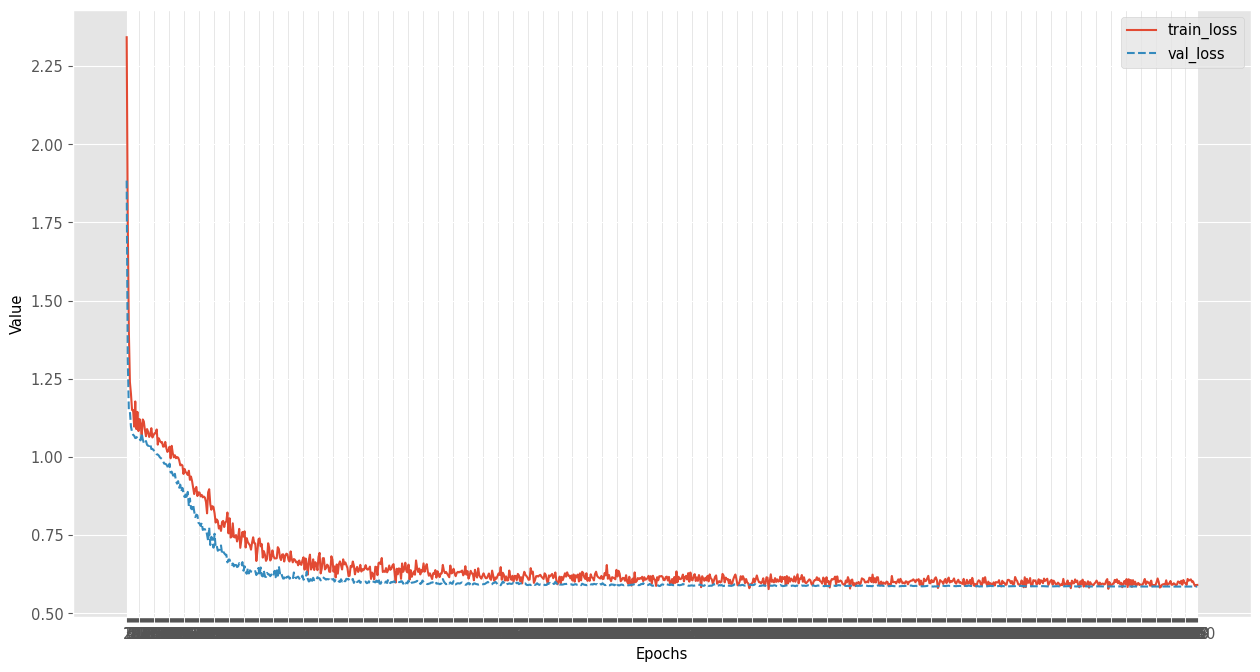

/home/amruthvvkp/projects/ai-playground/.venv/lib/python3.12/site-packages/ml_things/plot_functions.py:409: DeprecationWarning: `magnify` needs to have value in [0,1]! `1.2` will be converted to `0.1` as default.
  warnings.warn(f'`magnify` needs to have value in [0,1]! `{magnify}` will be converted to `0.1` as default.',


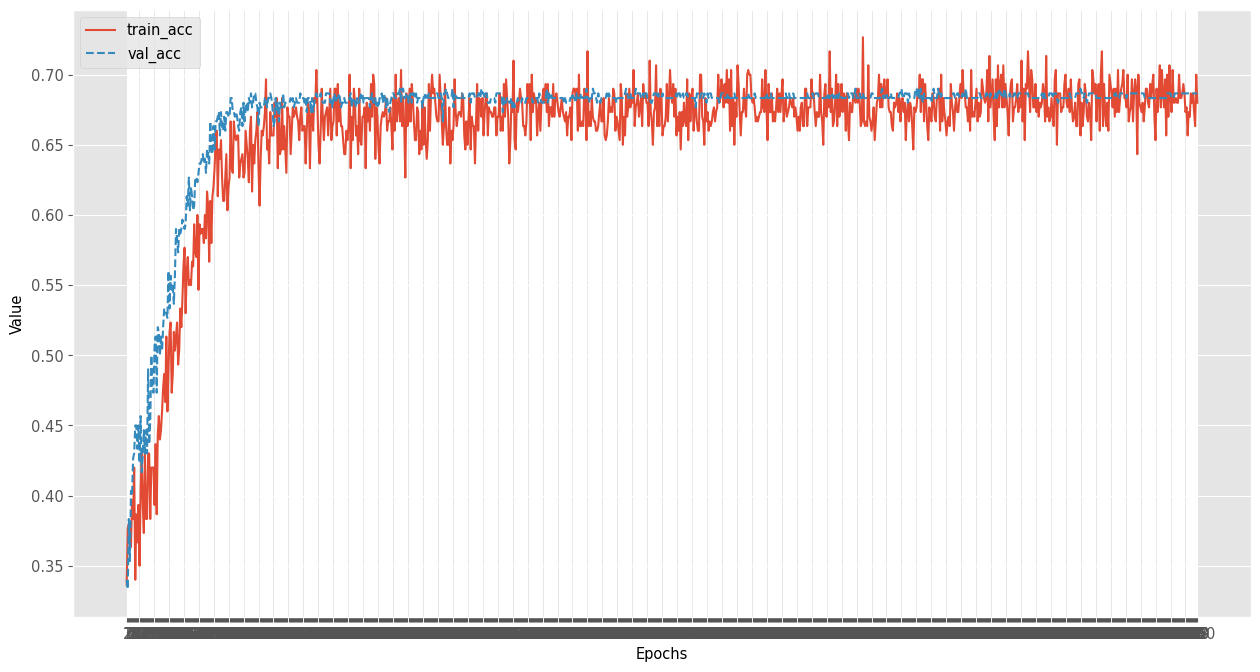

In [21]:
from ml_things import plot_dict, plot_confusion_matrix

# Plot loss
all_loss = {"train_loss": train_losses, "val_loss": val_losses}
all_acc = {"train_acc": train_accuracies, "val_acc": val_accuracies}

# Plot loss curves.
plot_dict(all_loss, use_xlabel="Epochs", use_ylabel="Value", use_linestyles=["-", "--"])

# Plot accuracy curves.
plot_dict(all_acc, use_xlabel="Epochs", use_ylabel="Value", use_linestyles=["-", "--"])

  0%|          | 0/10 [00:00<?, ?it/s]

              precision    recall  f1-score   support

         Low       0.69      0.64      0.67        92
      Medium       0.65      0.77      0.70       104
        High       0.73      0.64      0.68       104

    accuracy                           0.69       300
   macro avg       0.69      0.68      0.69       300
weighted avg       0.69      0.69      0.69       300

Normalized confusion matrix


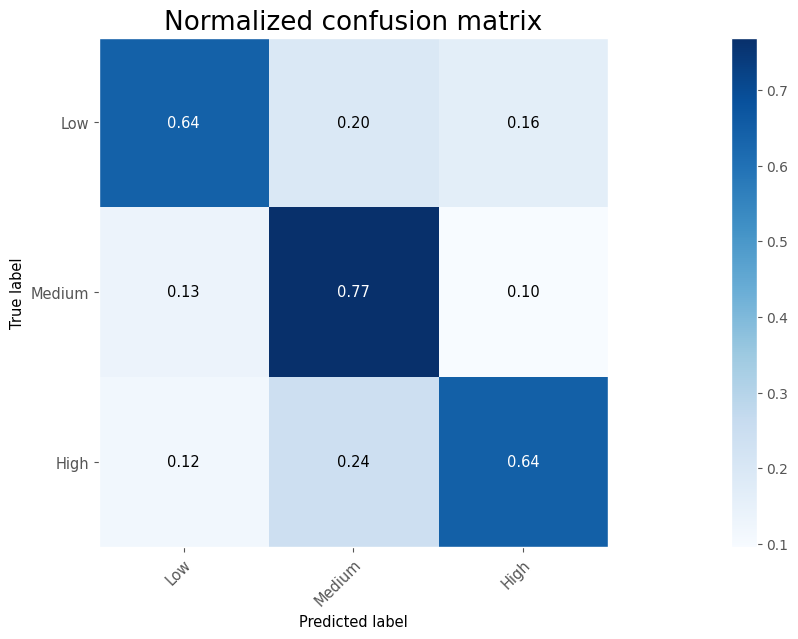

array([[0.64130435, 0.19565217, 0.16304348],
       [0.13461538, 0.76923077, 0.09615385],
       [0.11538462, 0.24038462, 0.64423077]])

In [22]:
from sklearn.metrics import classification_report

# Get prediction form model on validation data. This is where you should use
# your test data.
true_labels, predictions_labels, avg_epoch_loss = validation(val_dataloader, device)

# Create the evaluation report.
evaluation_report = classification_report(
    true_labels, predictions_labels, labels=list(labels_ids.values()), target_names=list(labels_ids.keys())
)
# Show the evaluation report.
print(evaluation_report)

# Plot confusion matrix.
plot_confusion_matrix(
    y_true=true_labels,
    y_pred=predictions_labels,
    classes=list(labels_ids.keys()),
    normalize=True,
    magnify=0.1,
)

In [30]:
max(all_acc["train_acc"])

0.7266666666666667